Geopandas Practice Sheet Homework

1) Complete the Hierarchy
- Shapely geometry -> an individual item
- GeoSeries -> geometry column 
- GeoDataFrame -> whole table 

In [2]:
import geopandas as gpd

parks = gpd.read_file("parks copy.geojson")

In [3]:
parks.geometry #Is a geoseries #shows us that they are polygons 

0    POLYGON ((1979700 789700, 1980900 789700, 1980...
1    POLYGON ((1981300 789900, 1982600 789900, 1982...
Name: geometry, dtype: geometry

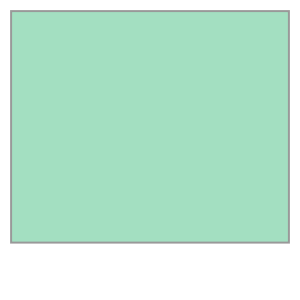

In [4]:
parks.geometry.iloc[0] #shapely geometry as it picks the first object

In [5]:
parks.iloc[0]# gives the first row of the parks GeoDataframe

park_id                                                    101
park_name                                             Oak Park
geometry     POLYGON ((1979700 789700, 1980900 789700, 1980...
Name: 0, dtype: object

In [6]:
parks.iloc[[0]] #gives the first row as a TABLE!!

,park_id,park_name,geometry
0,101,Oak Park,"POLYGON ((1979700 789700, 1980900 789700, 1980..."


In [7]:
list(parks.columns)


['park_id', 'park_name', 'geometry']

In [8]:
parks[['park_name','geometry']]

,park_name,geometry
0,Oak Park,"POLYGON ((1979700 789700, 1980900 789700, 1980..."
1,Pine Park,"POLYGON ((1981300 789900, 1982600 789900, 1982..."


In [9]:
parks.iloc[0:3]

,park_id,park_name,geometry
0,101,Oak Park,"POLYGON ((1979700 789700, 1980900 789700, 1980..."
1,102,Pine Park,"POLYGON ((1981300 789900, 1982600 789900, 1982..."


In [10]:
parks.geometry.geom_type

0    Polygon
1    Polygon
dtype: str

In [11]:
parks.crs
parks = parks.set_crs(epsg=2264, allow_override=True)

<Axes: xlabel='Easting [US survey foot]', ylabel='Northing [US survey foot]'>

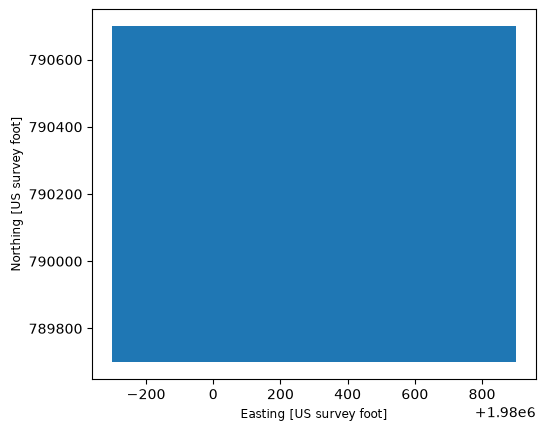

In [12]:
parks.iloc[[0]].plot()

<Axes: xlabel='Easting [US survey foot]', ylabel='Northing [US survey foot]'>

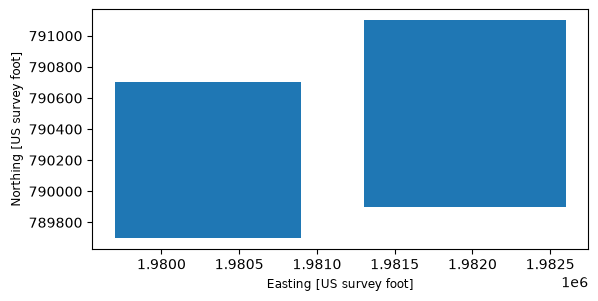

In [13]:
parks.plot()

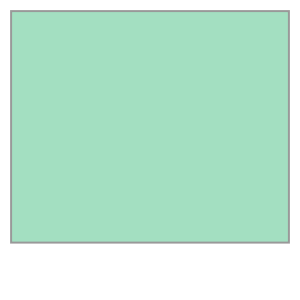

In [14]:
one_park = parks.geometry.iloc[0]
one_park

In [15]:
stops = gpd.read_file("bus_stops copy.geojson")
stops = stops.to_crs(epsg=2264)

In [16]:
stops.crs
stops_nc = stops.to_crs(epsg=2264)

In [17]:
parks["area_sqft"] = parks.geometry.area
parks['area_sqft']

0    1200000.0
1    1560000.0
Name: area_sqft, dtype: float64

In [18]:
parks = parks.set_crs(epsg=2264, allow_override=True)


In [19]:
park_1 = parks.geometry.iloc[0]
stops_nc.distance(park_1)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/shapely/measurement.py:81: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


0    inf
1    inf
2    inf
3    inf
4    inf
dtype: float64

In [20]:
urban = gpd.read_file("urban_area copy.geojson")
urban = urban.to_crs(epsg=2264)

In [21]:
gpd.sjoin(parks, urban, predicate="within")

,park_id,park_name,geometry,area_sqft,index_right,OBJECTID,URBANSER_,URBANSER_I,DATE,Shape__Area,Shape__Length
1,102,Pine Park,"POLYGON ((1981300 789900, 1982600 789900, 1982...",1560000.0,0,2,2,1,804470400000,7.150418e+08,158917.477493


In [22]:
joined = gpd.sjoin(stops,parks, predicate="within") #asks which stop is within the parks polygon
joined.groupby("index_right").size() # index right asks which park (right) mathced
#and .size() asks for a count

Series([], dtype: int64)

In [23]:
parks["near_stop"] = parks.geometry.apply(
    lambda park: stops_nc.intersects(park).any()
)

In [24]:
parks[parks["near_stop"]]

stop_buffers = stops_nc.buffer(500)
stop_buffers

0    POLYGON EMPTY
1    POLYGON EMPTY
2    POLYGON EMPTY
3    POLYGON EMPTY
4    POLYGON EMPTY
dtype: geometry